# We want to look at the eigenvalues of the training 

In [1]:
import torch
from torch.utils.data import DataLoader
from torchvision import transforms
from datasets import load_dataset
import numpy as np

from transformers import ViTForImageClassification, ViTConfig
from transformers import AutoImageProcessor, DefaultDataCollator
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from torch import nn

# For computing the Jacobian
from torch.autograd.functional import jacobian

# Needed for parallel 
from collections import OrderedDict

# Load the two models 

This is a bit involved as before; the ViT stuff is slightly different than the BERT 

In [306]:
checkpoint_0 = torch.load('cifar-models-serial/checkpoint_procs=2_0_epoch=30')
checkpoint_1 = torch.load('cifar-models-serial/checkpoint_procs=2_1_epoch=30')

In [ ]:
keys_0 = checkpoint_0['model_state'].keys()
keys_1 = checkpoint_1['model_state'].keys()

In [ ]:
# Load serial net for reconstruction 
model = torch.load('serialnet_12', weights_only=False)

# Reconstruction 

Note that here, we're putting it into the Huggingface model! Since we're doing $T = 12$ to show what the training looks like; if this changes, 

In [ ]:
new_dict = OrderedDict()
for key in keys_0:
    if 'parallel_nn' in key:
        split = key.split('.')
        split[1] = 'serial_nn'
        if int(split[2]) > counter:
            counter = int(split[2])
            
        split.insert(3, 'layer')
        new_key = '.'.join(split[1:])
        new_dict[new_key] = checkpoint_0['model_state'][key]
        
    else:
        new_key = key
        if 'close_nn' in key:
            # print(key)
            split = key.split('.')
            split[0] = 'close_nn'
            new_key = '.'.join(split)
        elif 'open_nn' in key: 
            split = key.split('.')
            split[0] = 'open_nn'
            new_key = '.'.join(split)
        new_dict[new_key] = checkpoint_0['model_state'][key]

keys_1 = checkpoint_1['model_state'].keys()
for key in keys_1:
    if 'parallel_nn' in key:
        split = key.split('.')
        split[1] = 'serial_nn'
        split[2] = str(int(split[2]) + counter + 1)
        split.insert(3, 'layer')
        
        new_key = '.'.join(split[1:])
        new_dict[new_key] = checkpoint_1['model_state'][key]
    else:
        new_dict[key] = checkpoint_1['model_state'][key]

# 'open_nn.embedding.cls_token', 'open_nn.embedding.position_embeddings', 'open_nn.embedding.patch_embeddings.projection.weight', 'open_nn.embedding.patch_embeddings.projection.bias'

In [ ]:
model.load_state_dict(new_dict)

# Calculate the eigenvalues of the linearized 

## First grab some REAL data

In [ ]:
dataset = load_dataset("cifar10")

train_transform = transforms.Compose([
                                      transforms.RandomHorizontalFlip(),
                                      transforms.RandomResizedCrop((32,32),scale=(0.8,1.0),ratio=(0.9,1.1)),
                                      transforms.ToTensor(),
                                      transforms.Normalize([0.49139968, 0.48215841, 0.44653091], [0.24703223, 0.24348513, 0.26158784])
                                     ])


def preprocess_train_images(examples):
    examples["pixel_values"] = [train_transform(image.convert("RGB")) for image in examples["img"]]
    return examples
    
# Apply transformations to the 'train' split
processed_train_dataset = dataset["train"].map(preprocess_train_images, batched=True, remove_columns=["img"])

# 3. Create a data collator
data_collator = DefaultDataCollator(return_tensors="pt")

train_dataloader = DataLoader(
    processed_train_dataset,
    shuffle=True,
    batch_size=128, # You can adjust this batch size
    collate_fn=data_collator,
    num_workers=4,
    drop_last=False,
)



In [ ]:
# First, make sure things seem alright
batch = next(iter(train_dataloader))
model = model.to('cuda')
batch['pixel_values'] = batch['pixel_values'].to('cuda')
print(torch.argmax(model(batch['pixel_values']), dim=1))
print(batch['labels'])

# Most of the label seems correct, good enough I think. 
# Note that the transformations are all different so that's why, but if ti

## Calculate what goes into the encoder network

In [ ]:
# First grab data 
batch = next(iter(train_dataloader))
print(batch['pixel_values'][0:1].shape) # Just grab the first image 
batch['pixel_values'] = batch['pixel_values'][0:1].to('cuda')
sample_input = model.open_nn(batch['pixel_values'])
print(sample_input.shape)

In [ ]:
# Pass values through whole model
model(batch['pixel_values'])

In [ ]:
with torch.no_grad():
    # First verify that this is all correct 
    sample_input = model.open_nn(batch['pixel_values'])
    attention_jacobians = []
    mlp_jacobians = []
    
    # Pass in to Transformer
    for l_index in tqdm(range(12)): 
        layer = model.serial_nn[l_index].layer.layer.layer
    
        # Define a function for the layer and grab Jacobian 
        # def attention_func(sample_input):
        #     return layer.attention(layer.layernorm_before(sample_input))
        # attention_jacobians.append(jacobian(attention_func, sample_input).reshape((65 * 128, 65 * 128)))
        
        # Split attention
        sample_input = attention_func(sample_input) + sample_input
    
        # Define a function for the MLP and grab jacobian
        # def mlp_func(sample_input):
        #     return layer.dense(layer.intermediate(layer.layernorm_after(sample_input)))
        # mlp_jacobians.append(jacobian(mlp_func, sample_input).reshape((65 * 128, 65 * 128)))
    
        # With MLP
        sample_input = mlp_func(sample_input) + sample_input
    
    # Pass into close layer; should match above
    print(model.close_nn(sample_input))

In [ ]:
for i in tqdm(range(12)): 
    print(torch.max(torch.abs(torch.linalg.eigvals(attention_jacobians[i]))))
    print(torch.max(torch.abs(torch.linalg.eigvals(mlp_jacobians[i]))))
    print('\n')

# Wrap the above in a function to loop over the serial/parallel training


In [ ]:
def get_dict(checkpoint_0, checkpoint_1):
    new_dict = OrderedDict()
    counter = 0
    for key in keys_0:
        if 'parallel_nn' in key:
            split = key.split('.')
            split[1] = 'serial_nn'
            if int(split[2]) > counter:
                counter = int(split[2])
                
            split.insert(3, 'layer')
            new_key = '.'.join(split[1:])
            new_dict[new_key] = checkpoint_0['model_state'][key]
            
        else:
            new_key = key
            if 'close_nn' in key:
                # print(key)
                split = key.split('.')
                split[0] = 'close_nn'
                new_key = '.'.join(split)
            elif 'open_nn' in key: 
                split = key.split('.')
                split[0] = 'open_nn'
                new_key = '.'.join(split)
            new_dict[new_key] = checkpoint_0['model_state'][key]
    
    keys_1 = checkpoint_1['model_state'].keys()
    for key in keys_1:
        if 'parallel_nn' in key:
            split = key.split('.')
            split[1] = 'serial_nn'
            split[2] = str(int(split[2]) + counter + 1)
            split.insert(3, 'layer')
            
            new_key = '.'.join(split[1:])
            new_dict[new_key] = checkpoint_1['model_state'][key]
        else:
            new_dict[key] = checkpoint_1['model_state'][key]

    return new_dict

In [303]:
def obtain_eigenvalues(epoch='30', serial='serial', batch=None, Tf=1):
    # Grab checkpoint 
    if Tf == 12:
        print('Loading Tf=12')
        checkpoint_0 = torch.load(f'cifar-models-{serial}/checkpoint_procs=2_0_epoch={epoch}')
        checkpoint_1 = torch.load(f'cifar-models-{serial}/checkpoint_procs=2_1_epoch={epoch}')
    else:
        checkpoint_0 = torch.load(f'cifar-models-{serial}/checkpoint_procs=2_0_epoch={epoch}_{Tf}')
        checkpoint_1 = torch.load(f'cifar-models-{serial}/checkpoint_procs=2_1_epoch={epoch}_{Tf}')
    

    # Load serial net for reconstruction 
    # This serialnet need to be for the correct! 
    model = torch.load(f'serialnet_12_{float(Tf)}', weights_only=False)
    model.load_state_dict(get_dict(checkpoint_0, checkpoint_1))
    model = model.to('cuda')

    with torch.no_grad():
        # First verify that this is all correct 
        sample_input = model.open_nn(batch['pixel_values'])
        
        attention_jacobians = []
        mlp_jacobians = []
        
        # Pass in to Transformer
        for l_index in tqdm(range(12)): 
            layer = model.serial_nn[l_index].layer.layer.layer
        
            # Define a function for the layer and grab Jacobian 
            def attention_func(sample_input):
                return layer.attention(layer.layernorm_before(sample_input))
            attention_jacobians.append(jacobian(attention_func, sample_input).reshape((65 * 128, 65 * 128)))
            
            # Split attention
            sample_input = Tf/12 *attention_func(sample_input) +  sample_input
        
            # Define a function for the MLP and grab jacobian
            def mlp_func(sample_input):
                return layer.dense(layer.intermediate(layer.layernorm_after(sample_input)))
            mlp_jacobians.append(jacobian(mlp_func, sample_input).reshape((65 * 128, 65 * 128)))
        
            # With MLP
            sample_input =Tf/12 *mlp_func(sample_input) +   sample_input
            
        
        # Pass into close layer; should match above
        # print(model.close_nn(sample_input))
        # print(model(batch['pixel_values']))
        assert torch.allclose(model.close_nn(sample_input), model(batch['pixel_values'])), "Outputs are not close enough!"

    attn_eigs = []
    mlp_eigs = []
    for i in tqdm(range(12)): 
        attn_eigs.append(
            torch.linalg.eigvals(attention_jacobians[i])
        )
        mlp_eigs.append(
            torch.linalg.eigvals(mlp_jacobians[i])
        )

    
    return attn_eigs,mlp_eigs

In [304]:
Tf = 12
all_attn_eigs, all_mlp_eigs = [], []
for epoch in tqdm(range(1, 31),desc="Epochs"):
    attn_eigs,mlp_eigs = obtain_eigenvalues(epoch=f'{epoch}', batch=batch, Tf=Tf)
    all_attn_eigs.append(attn_eigs)
    all_mlp_eigs.append(mlp_eigs)

data_to_save = {
    'all_attn_eigs': all_attn_eigs,
    'all_mlp_eigs': all_mlp_eigs
}

# Save the data to a file
torch.save(data_to_save, f'eigenvalues_data_deltat_{Tf}.pth')


Epochs:   0%|          | 0/30 [00:00<?, ?it/s]

Loading Tf=12


  0%|          | 0/12 [00:00<?, ?it/s]

  0%|          | 0/12 [00:00<?, ?it/s]

Loading Tf=12


...

  0%|          | 0/12 [00:00<?, ?it/s]

  0%|          | 0/12 [00:00<?, ?it/s]

Loading Tf=12


  0%|          | 0/12 [00:00<?, ?it/s]

  0%|          | 0/12 [00:00<?, ?it/s]

In [ ]:
Tf = .12
all_attn_eigs, all_mlp_eigs = [], []
for epoch in tqdm(range(1, 31),desc="Epochs"):
    attn_eigs,mlp_eigs = obtain_eigenvalues(epoch=f'{epoch}', batch=batch, Tf=Tf)
    all_attn_eigs.append(attn_eigs)
    all_mlp_eigs.append(mlp_eigs)

data_to_save = {
    'all_attn_eigs': all_attn_eigs,
    'all_mlp_eigs': all_mlp_eigs
}

# Save the data to a file
torch.save(data_to_save, f'eigenvalues_data_deltat_{Tf}.pth')


In [ ]:
# data_to_save = {
#     'all_attn_eigs': all_attn_eigs,
#     'all_mlp_eigs': all_mlp_eigs
# }

# # Save the data to a file
# torch.save(data_to_save, 'eigenvalues_data_deltat_1.pth')

# To load
loaded_data = torch.load('eigenvalues_data.pth')
all_attn_eigs_loaded = loaded_data['all_attn_eigs']
all_mlp_eigs_loaded = loaded_data['all_mlp_eigs']

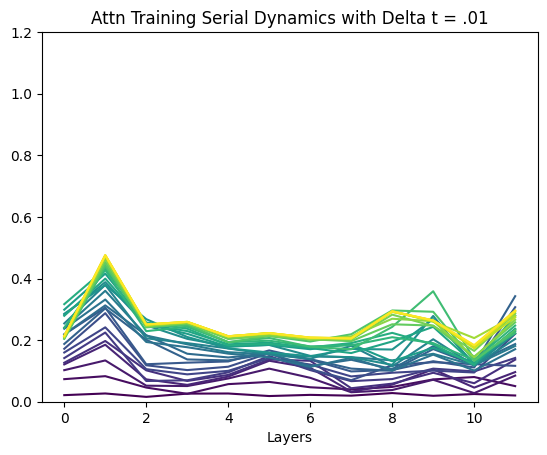

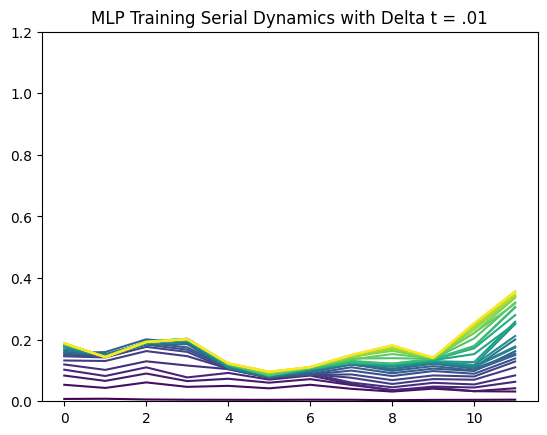

In [2]:

# To load
loaded_data = torch.load('eigenvalues_data_deltat_.01.pth')
all_attn_eigs_loaded = loaded_data['all_attn_eigs']
all_mlp_eigs_loaded = loaded_data['all_mlp_eigs']

colors = plt.cm.viridis(np.linspace(0, 1, 30))  # Use the viridis colormap
for i, epoch_data in enumerate(all_attn_eigs_loaded): 
    current_epoch = []
    for layer_data in epoch_data:
        current_epoch.append(
            torch.max(torch.abs(layer_data.real)).cpu().item() / 100
        )
        # current_epoch.append(
        #     torch.max(torch.abs(layer_data.imag)).cpu().item()
        # )

    plt.plot(current_epoch, color=colors[i], label=f'Epoch {i}')  # Set color for each epoch
# plt.legend()
plt.ylim(0, 1.2)
plt.title('Attn Training Serial Dynamics with Delta t = .01')
plt.xlabel('Layers')
plt.show()

colors = plt.cm.viridis(np.linspace(0, 1, 30))  # Use the viridis colormap
for i, epoch_data in enumerate(all_mlp_eigs_loaded): 
    current_epoch = []
    for layer_data in epoch_data:
        current_epoch.append(
            torch.max(torch.abs(layer_data.real)).cpu().item() / 100
        )
        # current_epoch.append(
        #     torch.max(torch.abs(layer_data.real)).cpu().item() 
        # )

    plt.plot(current_epoch, color=colors[i], label=f'Epoch {i}')  # Set color for each epoch
# plt.legend()
plt.ylim(0, 1.2)

plt.title('MLP Training Serial Dynamics with Delta t = .01')
plt.show()

<>:19: SyntaxWarning: invalid escape sequence '\D'
<>:40: SyntaxWarning: invalid escape sequence '\D'
<>:19: SyntaxWarning: invalid escape sequence '\D'
<>:40: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_1557851/3865784881.py:19: SyntaxWarning: invalid escape sequence '\D'
  plt.title('Attn Training Serial Dynamics with $\Delta t = 1$')
/tmp/ipykernel_1557851/3865784881.py:40: SyntaxWarning: invalid escape sequence '\D'
  plt.title('MLP Training Serial Dynamics with $\Delta t = 1$')


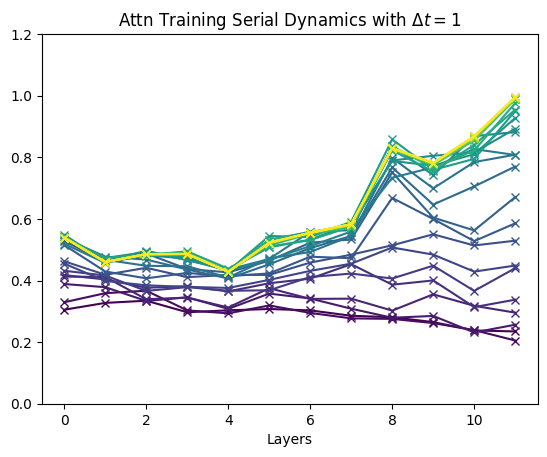

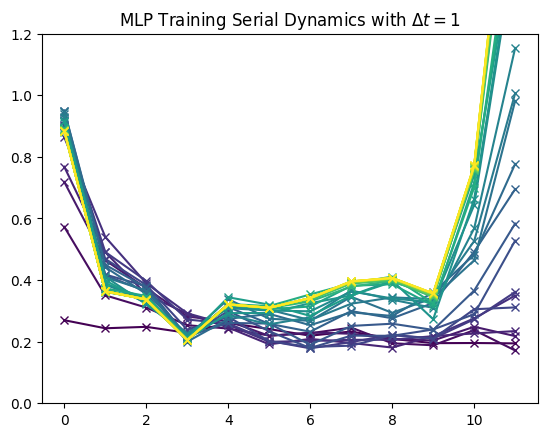

In [4]:

# To load
loaded_data = torch.load('eigenvalues_data_deltat_12.pth')
all_attn_eigs_loaded = loaded_data['all_attn_eigs']
all_mlp_eigs_loaded = loaded_data['all_mlp_eigs']

colors = plt.cm.viridis(np.linspace(0, 1, 30))  # Use the viridis colormap
for i, epoch_data in enumerate(all_attn_eigs_loaded): 
    current_epoch = []
    for layer_data in epoch_data:
        current_epoch.append(
            torch.max(torch.abs(layer_data)).cpu().item()
        )
        # current_epoch.append(
        #     torch.max(torch.abs(layer_data.imag)).cpu().item()
        # )

    plt.plot(current_epoch, 'x-', color=colors[i], label=f'Epoch {i}')  # Set color for each epoch
# plt.legend()
plt.title('Attn Training Serial Dynamics with $\Delta t = 1$')
plt.xlabel('Layers')
plt.ylim(0, 1.2)

plt.show()

colors = plt.cm.viridis(np.linspace(0, 1, 30))  # Use the viridis colormap
for i, epoch_data in enumerate(all_mlp_eigs_loaded): 
    current_epoch = []
    for layer_data in epoch_data:
        current_epoch.append(
            torch.max(torch.abs(layer_data)).cpu().item()
        )
        # current_epoch.append(
        #     torch.max(torch.abs(layer_data.real)).cpu().item()
        # )

    plt.plot(current_epoch,'x-',  color=colors[i], label=f'Epoch {i}')  # Set color for each epoch
# plt.legend()
plt.ylim(0, 1.2)

plt.title('MLP Training Serial Dynamics with $\Delta t = 1$')
plt.show()

<>:18: SyntaxWarning: invalid escape sequence '\D'
<>:32: SyntaxWarning: invalid escape sequence '\D'
<>:18: SyntaxWarning: invalid escape sequence '\D'
<>:32: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_1557851/2238925806.py:18: SyntaxWarning: invalid escape sequence '\D'
  axs[0].set_title('Attn Jacobian with $\Delta t = 1$')
/tmp/ipykernel_1557851/2238925806.py:32: SyntaxWarning: invalid escape sequence '\D'
  axs[1].set_title('MLP Jacobian with $\Delta t = 1$')


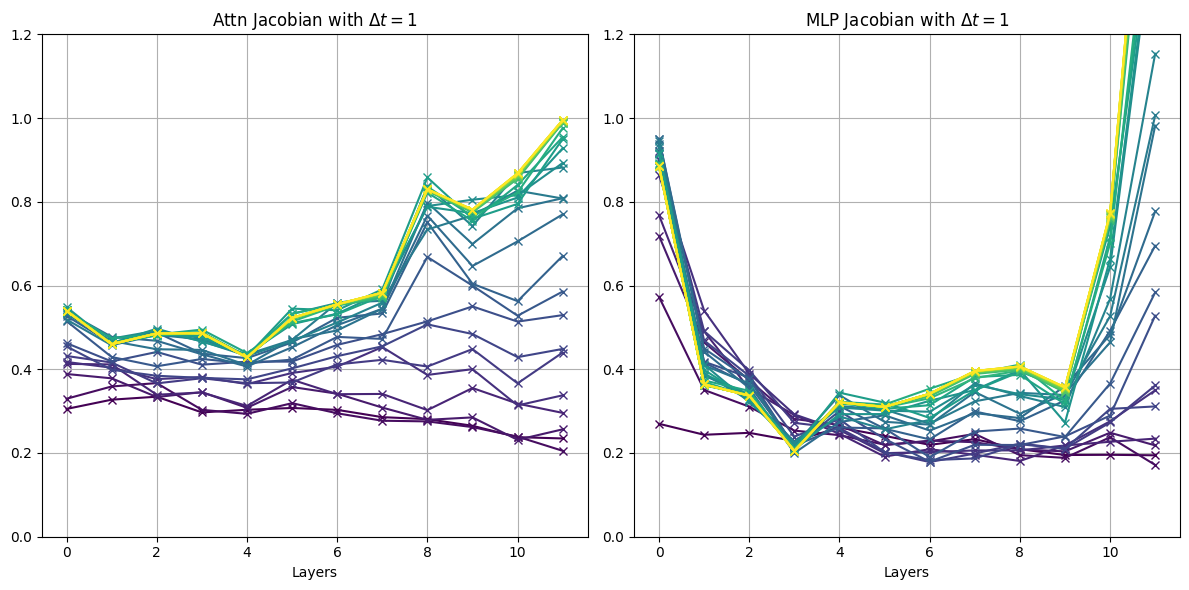

In [7]:
# Load data
loaded_data = torch.load('eigenvalues_data_deltat_12.pth')
all_attn_eigs_loaded = loaded_data['all_attn_eigs']
all_mlp_eigs_loaded = loaded_data['all_mlp_eigs']

# Create subplots
fig, axs = plt.subplots(1, 2, figsize=(12, 6))  # 1 row, 2 columns

# Plot Attention Eigenvalues
colors = plt.cm.viridis(np.linspace(0, 1, 30))  # Use the viridis colormap
for i, epoch_data in enumerate(all_attn_eigs_loaded): 
    current_epoch = []
    for layer_data in epoch_data:
        current_epoch.append(torch.max(torch.abs(layer_data)).cpu().item())
    
    axs[0].plot(current_epoch, 'x-', color=colors[i], label=f'Epoch {i}')  # Set color for each epoch

axs[0].set_title('Attn Jacobian with $\Delta t = 1$')
axs[0].set_xlabel('Layers')
axs[0].set_ylim(0, 1.2)
axs[0].grid(True)
# axs[0].legend(loc='upper right', bbox_to_anchor=(1.15, 1), title='Epochs', fontsize='small')

# Plot MLP Eigenvalues
for i, epoch_data in enumerate(all_mlp_eigs_loaded): 
    current_epoch = []
    for layer_data in epoch_data:
        current_epoch.append(torch.max(torch.abs(layer_data)).cpu().item())
    
    axs[1].plot(current_epoch, 'x-', color=colors[i], label=f'Epoch {i}')  # Set color for each epoch

axs[1].set_title('MLP Jacobian with $\Delta t = 1$')
axs[1].set_xlabel('Layers')
axs[1].set_ylim(0, 1.2)
axs[1].grid(True)
# axs[1].legend(loc='upper right', bbox_to_anchor=(1.15, 1), title='Epochs', fontsize='small')

# Adjust layout
plt.tight_layout()
plt.show()